In [2]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt

Write a program to read a color image and convert it to grayscale image. Display both the images in 2 different windows using cv2.

In [3]:
lenna_path = '../images/lenna.png'

In [4]:
img = cv.imread(lenna_path)
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

cv.imshow("OG Image", img)
cv.imshow("Gray Image", gray_img)

cv.waitKey(0)
cv.destroyAllWindows()

Read an image and reduce the spatial resolution to 50%, and 25%, etc. Analyze the result.

In [6]:
height, width, channels = img.shape

img_50 = cv.resize(img, dsize=None, fx=0.5, fy=0.5)
img_25 = cv.resize(img, (width // 4, height // 4))

cv.imshow("Original", img)
cv.imshow("50%", img_50)
cv.imshow("25%", img_25)

cv.waitKey(0)
cv.destroyAllWindows()

Read an image, apply the gray level resolution from 1 to 8. Write your inference.

In [7]:
concat_img = np.zeros((height, width), dtype=np.uint8)

for bits in range(8, 0, -1):
    shift = 8 - bits
    gray_lvl_img = (gray_img >> shift) << shift
    cv.putText(gray_lvl_img, f"{bits}-bit", (10, 30), 0, 1, 0, 1)
    concat_img = cv.hconcat([concat_img, gray_lvl_img])

cv.imshow("Grayscale Levels", concat_img)
cv.waitKey(0)
cv.destroyAllWindows()

Store image of one format into other file formats.  Write a program to analyze the size of the resulting files.

In [7]:
cv.imwrite("../images/lenna.jpg", img)
cv.imwrite("../images/lenna.bmp", img)
cv.imwrite("../images/lenna.tif", img)

print("PNG", os.path.getsize("../images/lenna.png"))
print("JPG:", os.path.getsize("../images/lenna.jpg"))
print("BMP:", os.path.getsize("../images/lenna.bmp"))
print("TIF:", os.path.getsize("../images/lenna.tif"))

PNG 113068
JPG: 29584
BMP: 188054
TIF: 152186


Download an image of type ‘tif’.   Save this image as ‘jpg’ with different quality factor ranging from 10 to 100.  Analyze the relation between the quality factor and the file size.

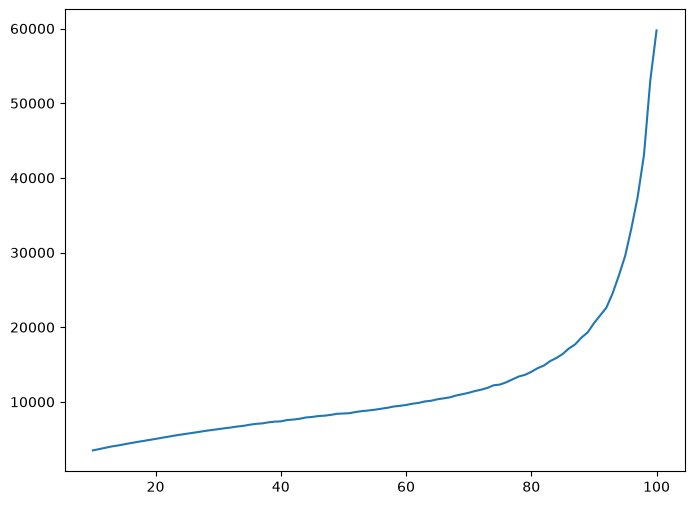

In [8]:
tif_img = cv.imread("../images/lenna.tif")

quality, size = [], []

for q in range(10, 101):
    name = f"lenna_{q}.jpg"
    path = f"../images/lenna_qualities/{name}"

    cv.imwrite(path, tif_img, [cv.IMWRITE_JPEG_QUALITY, q])

    quality.append(q)
    size.append(os.path.getsize(path))

plt.figure(figsize=(8, 6))
plt.plot(quality, size)
plt.show()

Write programs to implement the following arithmetic operations on 2 images

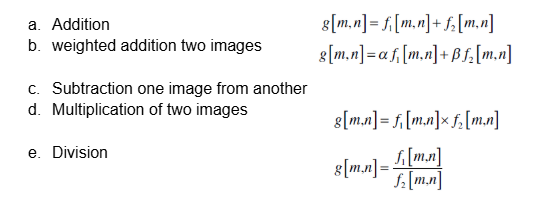

In [12]:
img1 = np.zeros((300, 300), dtype=np.uint8)
img2 = np.zeros((300, 300), dtype=np.uint8)

cv.circle(img1, (120, 100), 80, 255, -1) * 100
cv.rectangle(img2, (100, 100), (250, 200), 255, -1) * 2

add = img1 + img2
w_add = 0.5 * img1 + 0.5 * img2
sub = img1 - img2
mul = img1 * img2
div = img1 / (img2 + 1)
 
cv.imshow("Image 1 - Circle", img1)
cv.imshow("Image 2 - Rectangle", img2)
cv.imshow("Addition", add)
cv.imshow("Weighted Addition", w_add)
cv.imshow("Subtraction", sub)
cv.imshow("Multiplication", mul)
cv.imshow("Division", div)

cv.waitKey(0)
cv.destroyAllWindows()


C:\Users\premd\AppData\Local\Temp\ipykernel_17464\139557529.py:11: RuntimeWarning: divide by zero encountered in divide
  div = img1 / (img2 + 1)
C:\Users\premd\AppData\Local\Temp\ipykernel_17464\139557529.py:11: RuntimeWarning: invalid value encountered in divide
  div = img1 / (img2 + 1)


Write programs to implement the logical operations (AND, OR, XOR and NOT) on 2 images.

In [16]:
height, width = 300, 300

img1 = np.zeros((height, width), dtype=np.uint8)
img2 = np.zeros((height, width), dtype=np.uint8)

cv.circle(img1, (100, height // 2), 80, 255, -1)
cv.circle(img2, (width - 100, height // 2), 80, 255, -1)

and_img = np.zeros((height, width), dtype=np.uint8)
or_img = np.zeros((height, width), dtype=np.uint8)
xor_img = np.zeros((height, width), dtype=np.uint8)
not_img = np.zeros((height, width), dtype=np.uint8)

for i in range(height):
    for j in range(width):
        and_img[i, j] = img1[i, j] & img2[i, j]
        or_img[i, j] = img1[i, j] | img2[i, j]
        xor_img[i, j] = img1[i, j] ^ img2[i, j]
        not_img[i, j] = ~img1[i, j]

cv.imshow("Image 1", img1)
cv.imshow("Image 2", img2)
cv.imshow("AND", and_img)
cv.imshow("OR", or_img)
cv.imshow("XOR", xor_img)
cv.imshow("NOT", not_img)

cv.waitKey(0)
cv.destroyAllWindows()

# and_img = cv.bitwise_and(img1, img2)
# or_img = cv.bitwise_or(img1, img2)
# xor_img = cv.bitwise_xor(img1, img2)
# not_img = cv.bitwise_not(img1)